In [52]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import joblib
%matplotlib inline

In [53]:
# Load Dataset
df = pd.read_csv("../data/Mall_Customers.csv")

In [54]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [55]:
df.shape

(200, 5)

In [56]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [58]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [59]:
# check for Missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [60]:
# check for Duplicate rows
df.duplicated().sum()

np.int64(0)

In [63]:
# check for Data types
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [65]:
df.columns = [
    "CustomerID",
    "Gender",
    "Age",
    "Annual_Income",
    "Spending_Score"
]
df.head()


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


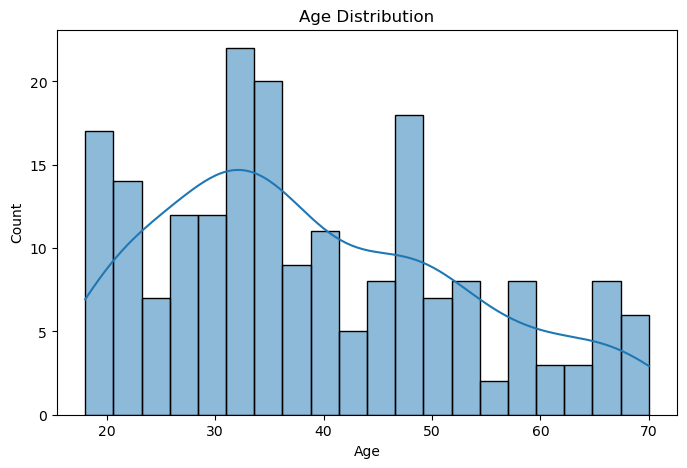

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.savefig("../images/age_distribution.png",
            bbox_inches="tight")

plt.show()

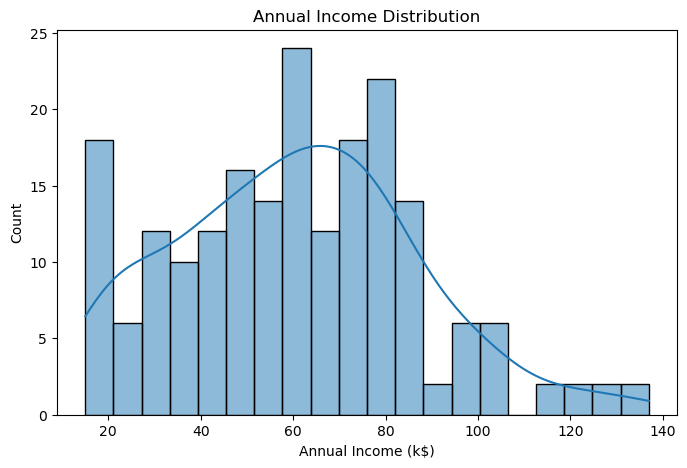

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Annual_Income",
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")

plt.savefig("../images/income_distribution.png",
            bbox_inches="tight")

plt.show()

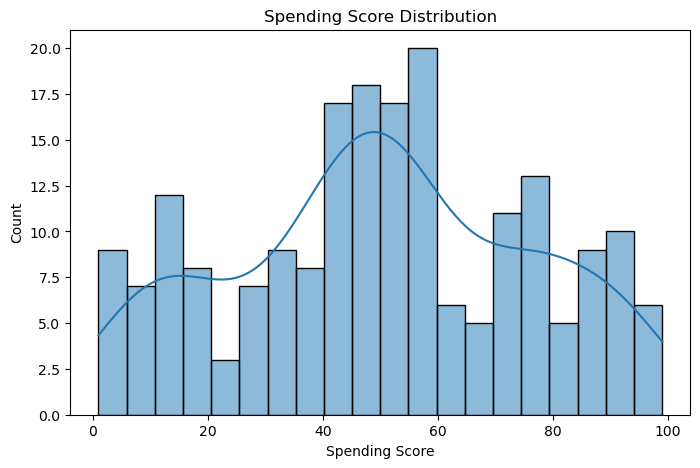

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Spending_Score",
    bins=20,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

plt.savefig("../images/spending_distribution.png",
            bbox_inches="tight")

plt.show()

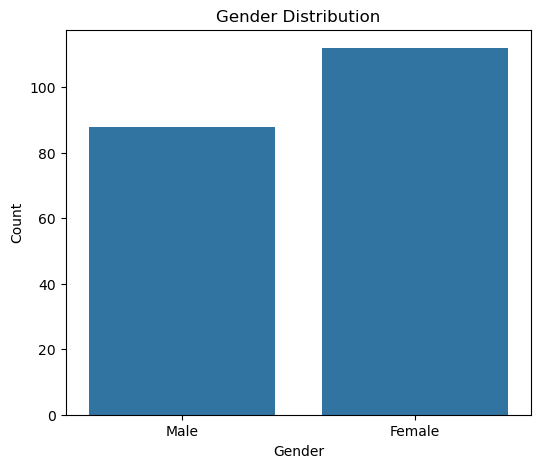

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("../images/gender_distribution.png",
            bbox_inches="tight")

plt.show()

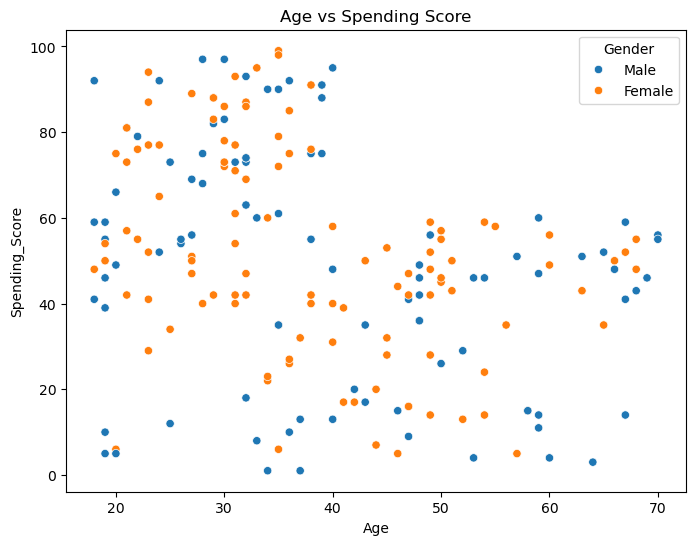

In [70]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending_Score",
    hue="Gender"
)

plt.title("Age vs Spending Score")

plt.savefig("../images/age_vs_spending.png",
            bbox_inches="tight")

plt.show()

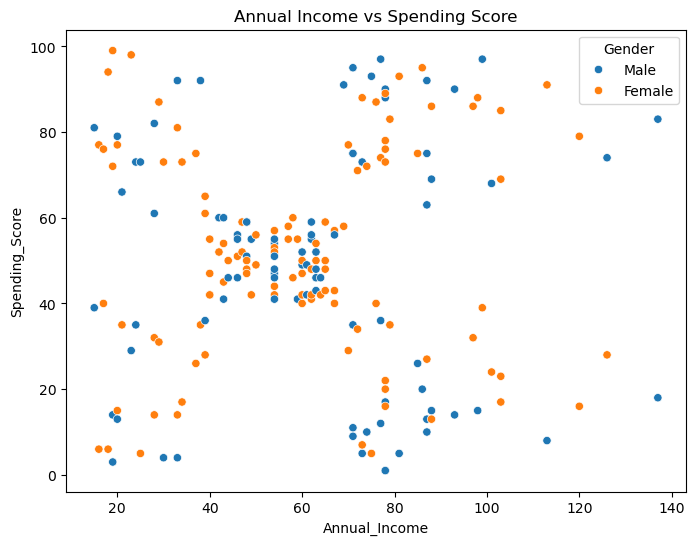

In [71]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Gender"
)

plt.title("Annual Income vs Spending Score")

plt.savefig("../images/income_vs_spending.png",
            bbox_inches="tight")

plt.show()

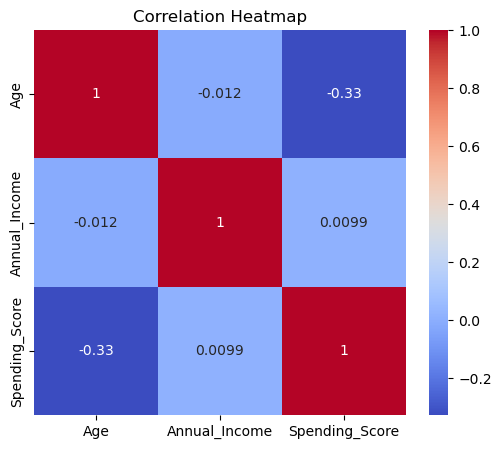

In [72]:
plt.figure(figsize=(6,5))

corr = df.drop(columns="CustomerID").corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png",
            bbox_inches="tight")

plt.show()

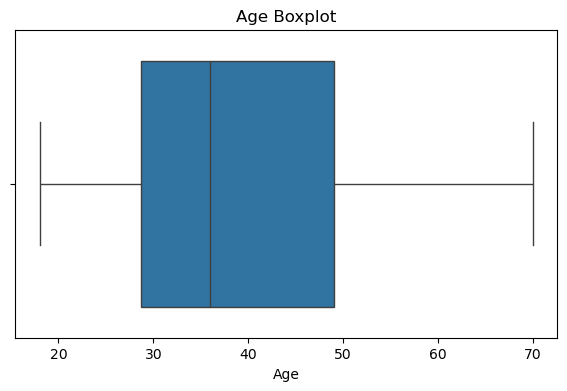

In [75]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df["Age"])

plt.title("Age Boxplot")

plt.show()

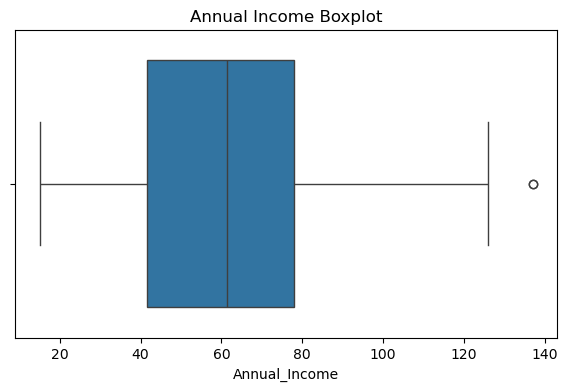

In [77]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df["Annual_Income"])

plt.title("Annual Income Boxplot")

plt.show()

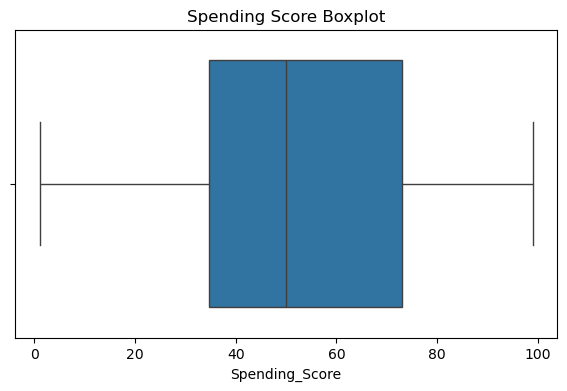

In [78]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df["Spending_Score"])

plt.title("Spending Score Boxplot")

plt.show()

In [79]:
# Selecting features for clustering

X = df[["Annual_Income", "Spending_Score"]]
X.head()

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [81]:
#Finding the Optimal Number of Clusters

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid

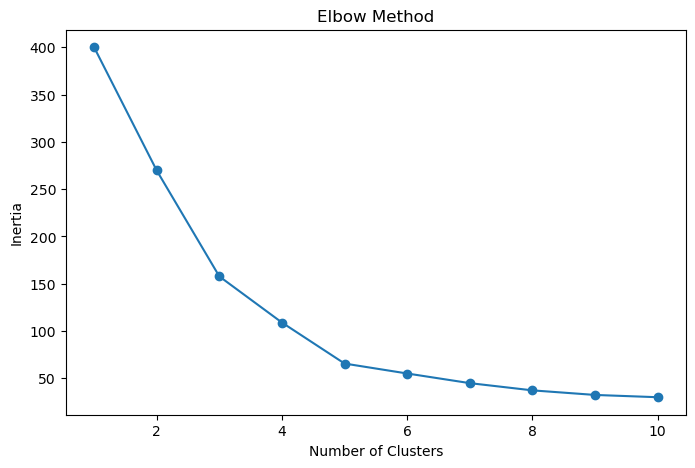

In [83]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.savefig("../images/elbow_method.png",
            bbox_inches="tight")

plt.show()

In [84]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid

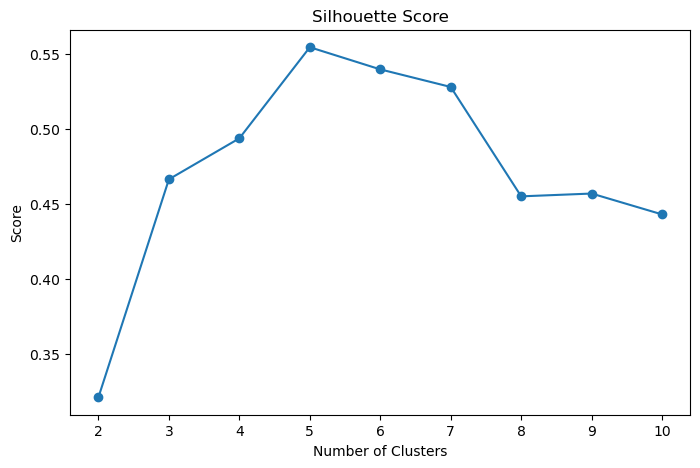

In [85]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.savefig("../images/silhouette_score.png",
            bbox_inches="tight")

plt.show()

In [86]:
for k, score in zip(range(2,11), silhouette_scores):
    print(f"k = {k}: {score:.3f}")

k = 2: 0.321
k = 3: 0.467
k = 4: 0.494
k = 5: 0.555
k = 6: 0.540
k = 7: 0.528
k = 8: 0.455
k = 9: 0.457
k = 10: 0.443


In [36]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head()



d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [90]:
df["Cluster"] = clusters

cluster_map = {
    0: "Balanced Mainstream Customers",
    1: "Premium High-Value Customers",
    2: "Budget Enthusiastic Spenders",
    3: "High Income Low Engagement Customers",
    4: "Low Value Conservative Customers"
}

df["Segment"] = df["Cluster"].map(cluster_map)

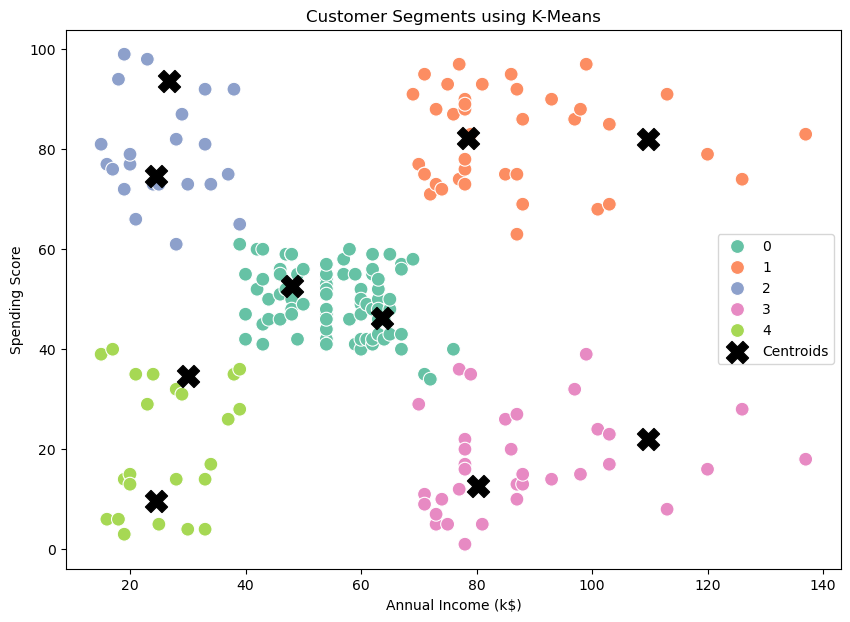

In [92]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:,0],
    scaler.inverse_transform(kmeans.cluster_centers_)[:,1],
    c="black",
    marker="X",
    s=250,
    label="Centroids"
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()

plt.savefig(
    "../images/customer_clusters.png",
    bbox_inches="tight"
)

plt.show()

In [94]:
cluster_summary = (
    df.groupby("Cluster")
      .agg({
          "Age": "mean",
          "Annual_Income": "mean",
          "Spending_Score": "mean",
          "CustomerID": "count"
      })
      .rename(columns={"CustomerID": "Customers"})
      .round(2)
)

cluster_summary

,Age,Annual_Income,Spending_Score,Customers
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


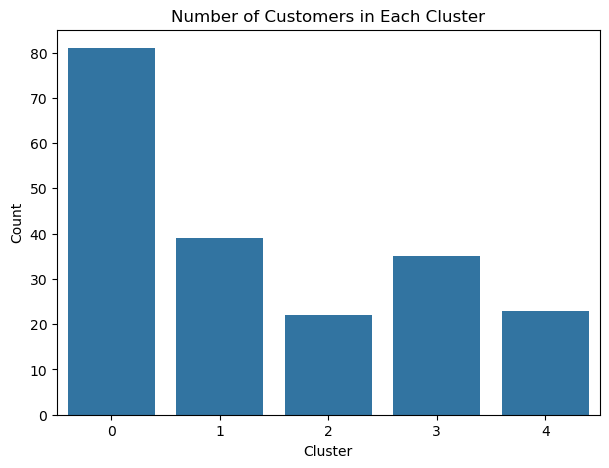

In [95]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.savefig(
    "../images/cluster_sizes.png",
    bbox_inches="tight"
)

plt.show()

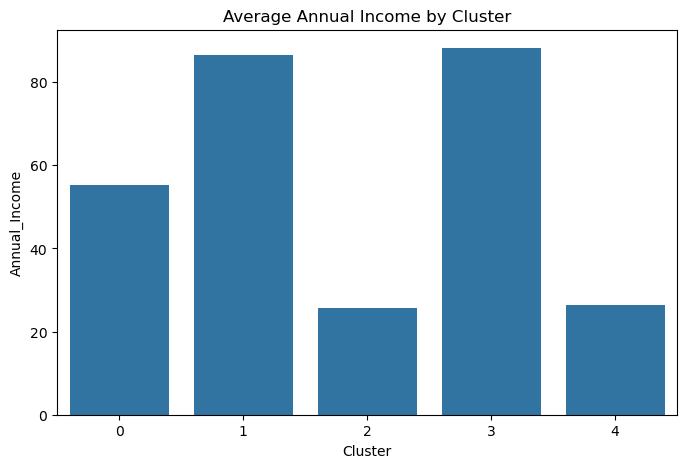

In [96]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="Cluster",
    y="Annual_Income"
)

plt.title("Average Annual Income by Cluster")

plt.savefig(
    "../images/income_by_cluster.png",
    bbox_inches="tight"
)

plt.show()

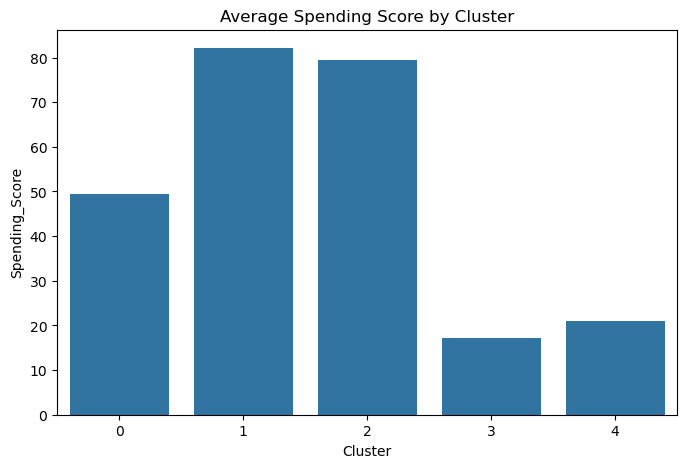

In [97]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cluster_summary.reset_index(),
    x="Cluster",
    y="Spending_Score"
)

plt.title("Average Spending Score by Cluster")

plt.savefig(
    "../images/spending_by_cluster.png",
    bbox_inches="tight"
)

plt.show()

In [98]:
df["Cluster"] = clusters

cluster_map = {
    0: "Balanced Mainstream Customers",
    1: "Premium High-Value Customers",
    2: "Budget Enthusiastic Spenders",
    3: "High Income Low Engagement Customers",
    4: "Low Value Conservative Customers"
}

df["Segment"] = df["Cluster"].map(cluster_map)

In [104]:
X = df[["Annual_Income", "Spending_Score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

# Save trained KMeans model
joblib.dump(kmeans,"../models/kmeans_model.pkl")

# Save scaler
joblib.dump(scaler,"../models/scaler.pkl")

# Save clustered dataset
df.to_csv("../outputs/customer_segments.csv",index=False
)

print("Model, scaler, and clustered dataset saved successfully!")

Model, scaler, and clustered dataset saved successfully!


d:\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
